In [1]:
from matplotlib import pyplot as plt
# from matplotlib.patches import Patch
import matplotlib.patches as mpatches
import numpy as np

from pySTDLM.PostProcessing import *

In [2]:
plt.rcParams['figure.dpi'] = 300

In [3]:
normDir = '/Data1/zane/Zenodo/isosplicer_code_and_data/Data/SRSF6_MCF7_Grad_Norm/'
hypDir = '/Data1/zane/Zenodo/isosplicer_code_and_data/Data/SRSF6_MCF7_Grad_Hyp/'

In [4]:
def getSplicingRatio(filename, ir=False):

    # print(filename)

    mrna = []
    fractions = []

    fileHandle = openLMFile(filename)
    rep = 1
    avTot = None
    
    CMEspecies = getSpecies(fileHandle)
    specList = [spec.decode('utf-8') for spec in CMEspecies]
    
    for i in range(len(specList)):
        spec = specList[i]
        CMEid = CMEspecies[i]
        # print(spec)
        if spec.startswith('m_'):
            # print(spec)
            mrna.append(CMEid)

    mrna.sort()

    for spec in mrna:
        av, var, t = getAvgVarTrace(fileHandle, specie=spec)
        if avTot is None:
            avTot = av
        else:
            avTot = avTot + av

        fractions.append(av[-1])

    if avTot[-1]<0.9999:
        print(f'Incomplete splicing in {filename} {avTot[-1]}')
        if ir:
            fractions[0] = fractions[0] + (1-avTot[-1])
    
    closeLMFile(fileHandle)

    return fractions

Incomplete splicing in /Data1/zane/Zenodo/isosplicer_code_and_data/Data/SRSF6_MCF7_Grad_Norm/SRSF6_7.lm 0.8009999999999999
Incomplete splicing in /Data1/zane/Zenodo/isosplicer_code_and_data/Data/SRSF6_MCF7_Grad_Hyp/SRSF6_7.lm 0.8119999999999999
Incomplete splicing in /Data1/zane/Zenodo/isosplicer_code_and_data/Data/SRSF6_MCF7_Grad_Norm/SRSF6_8.lm 0.991
Incomplete splicing in /Data1/zane/Zenodo/isosplicer_code_and_data/Data/SRSF6_MCF7_Grad_Hyp/SRSF6_8.lm 0.986
Incomplete splicing in /Data1/zane/Zenodo/isosplicer_code_and_data/Data/SRSF6_MCF7_Grad_Norm/SRSF6_9.lm 0.987
Incomplete splicing in /Data1/zane/Zenodo/isosplicer_code_and_data/Data/SRSF6_MCF7_Grad_Hyp/SRSF6_9.lm 0.987
Incomplete splicing in /Data1/zane/Zenodo/isosplicer_code_and_data/Data/SRSF6_MCF7_Grad_Norm/SRSF6_13.lm 0.9139999999999999
Incomplete splicing in /Data1/zane/Zenodo/isosplicer_code_and_data/Data/SRSF6_MCF7_Grad_Hyp/SRSF6_13.lm 0.921
Incomplete splicing in /Data1/zane/Zenodo/isosplicer_code_and_data/Data/SRSF6_MCF7_

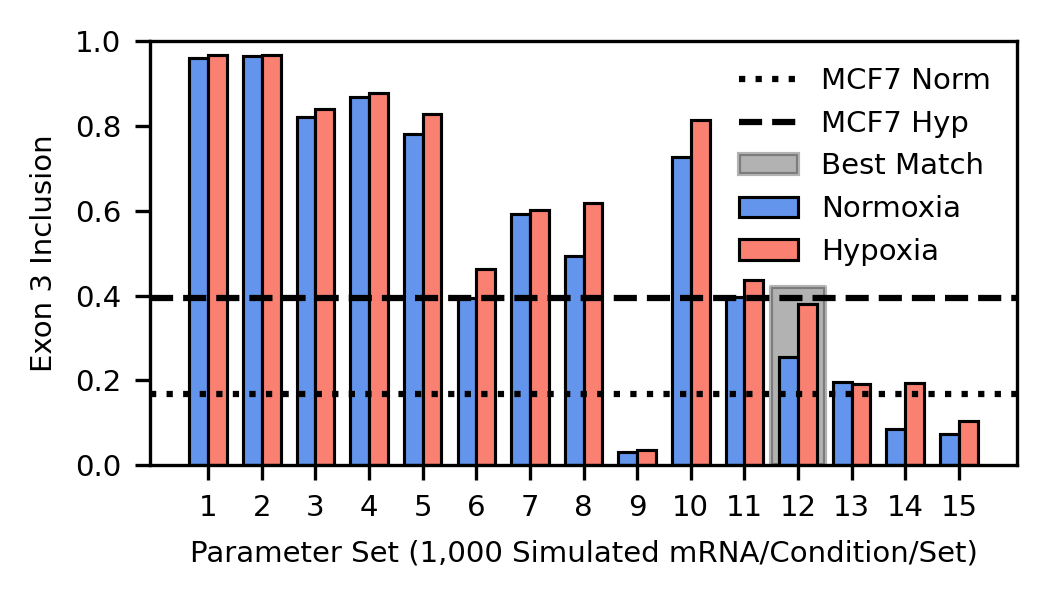

In [5]:
plt.rcParams.update({'font.size': 7})

fig, ax = plt.subplots(figsize=(3.5,2))

barwidth = 0.35
alpha = 0.75

ax.axhline(y=((0.174+0.161)/2), color='k', linestyle=':', label='MCF7 Norm')
ax.axhline(y=((0.418+0.368)/2), color='k', linestyle='--', label='MCF7 Hyp')

xb = np.linspace(11.5, 12.5, 10)
ax.fill_between(xb, 0, 0.42, color='k', alpha=0.3, label='Best Match')

normInc = []
hypInc = []

normIncIr = []
hypIncIr = []

for i in range(1,16):
    filename = f'{normDir}SRSF6_{i}.lm'
    fin = getSplicingRatio(filename)
    normInc.append(fin[0])

    # filename = f'{normDir}SRSF6_{i}.lm'
    # fin = getSplicingRatio(filename, ir=True)
    # normIncIr.append(fin[0])

    filename = f'{hypDir}SRSF6_{i}.lm'
    fih = getSplicingRatio(filename)
    hypInc.append(fih[0])

    # filename = f'{hypDir}SRSF6_{i}.lm'
    # fih = getSplicingRatio(filename, ir=True)
    # hypIncIr.append(fih[0])


x1 = np.arange(len(normInc)) + 1

print(normInc)
print(hypInc)

# ax.bar(x1 - barwidth/2, normIncIr, width=barwidth, color='cornflowerblue', edgecolor='k', linewidth=0.75, hatch='/')
# ax.bar(x1 + barwidth/2, hypIncIr, width=barwidth, color='salmon', edgecolor='k', linewidth=0.75, hatch='/')

ax.bar(x1 - barwidth/2, normInc, width=barwidth, color='cornflowerblue', edgecolor='k', linewidth=0.75, label='Normoxia')
ax.bar(x1 + barwidth/2, hypInc, width=barwidth, color='salmon', edgecolor='k', linewidth=0.75, label='Hypoxia')

ax.set_ylabel('Exon 3 Inclusion')
ax.set_xlabel('Parameter Set (1,000 Simulated mRNA/Condition/Set)')

ax.set_ylim(0,1)

ax.xaxis.set_ticks(x1)

ax.legend(loc='upper right', frameon=False)

plt.tight_layout()

plt.savefig('./norm_hyp_SRSF6_grad.png', transparent=True)

In [6]:
hypInc

[0.967,
 0.967,
 0.84,
 0.878,
 0.829,
 0.463,
 0.602,
 0.619,
 0.035,
 0.813,
 0.436,
 0.381,
 0.192,
 0.194,
 0.104]